In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
df_final = pd.read_csv('data.csv')

In [5]:
df_final

,Date,Week,Price_A,Price_B,Price_C,Sales_A
0,2024-01-08,1,12.25,11.44,12.81,5222
1,2024-01-15,2,11.93,11.66,14.81,6757
2,2024-01-22,3,12.32,12.25,12.84,6052
3,2024-01-29,4,12.76,11.57,13.18,4539
4,2024-02-05,5,11.88,11.60,13.07,6012
...,...,...,...,...,...,...
99,2025-12-01,100,11.88,11.92,12.15,4615
100,2025-12-08,101,11.29,10.95,12.83,4825
101,2025-12-15,102,11.79,11.12,12.38,5574
102,2025-12-22,103,11.83,11.71,12.37,5453


In [6]:
log_sales_A = np.log(df_final['Sales_A'].values)
log_price_A = np.log(df_final['Price_A'].values)
log_price_B = np.log(df_final['Price_B'].values)
log_price_C = np.log(df_final['Price_C'].values)
week_index = df_final['Week'].values

In [7]:
with pm.Model() as elasticity_model:
    # ------------------------------------
    # Priors for Elasticities (Coefficients)
    # Own-price: Expected to be negative (mu < 0)
    E_A = pm.Normal('E_A', mu=-2.0, sigma=1.0) 
    # Cross-prices: Expected to be positive (substitutes, mu > 0)
    E_B = pm.Normal('E_B', mu=1.0, sigma=1.0)
    E_C = pm.Normal('E_C', mu=1.0, sigma=1.0)
    
    # Intercept and Noise
    intercept = pm.Normal('Intercept', mu=np.mean(log_sales_A), sigma=1)
    sigma = pm.HalfCauchy('sigma', beta=1)
    
    # Seasonality parameters (annual cycle)
    # This accounts for the base sales movement not caused by prices
    season_amplitude = pm.HalfNormal('season_amplitude', sigma=0.1)
    seasonal_effect = season_amplitude * pt.sin(2 * np.pi * week_index / 52.0)
    
    # Linear Predictor (mu = Log(Expected Sales))
    mu = (
        intercept +
        E_A * log_price_A +
        E_B * log_price_B +
        E_C * log_price_C +
        seasonal_effect
    )
    
    # Likelihood (Observed Sales)
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=log_sales_A)
    
    # Sample the posterior distribution
    idata = pm.sample(2000, tune=1000, target_accept=0.9)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [E_A, E_B, E_C, Intercept, sigma, season_amplitude]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 62 seconds.


In [8]:
az.summary(idata, var_names=['E_A', 'E_B', 'E_C', 'Intercept'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
E_A,-2.916,0.215,-3.297,-2.499,0.003,0.002,5703.0,4944.0,1.0
E_B,1.895,0.246,1.420,2.346,0.003,0.002,5480.0,5159.0,1.0
E_C,1.061,0.172,0.736,1.383,0.002,0.002,6496.0,5153.0,1.0
Intercept,8.458,0.689,7.167,9.758,0.010,0.007,4901.0,4579.0,1.0


In [9]:
COST_A = 8.00  # Marginal cost per unit of Brand A
COMP_PRICE_B = df_final['Price_B'].iloc[-1] # Last observed price for B
COMP_PRICE_C = df_final['Price_C'].iloc[-1] # Last observed price for C

# Retrieve the posterior mean elasticities and intercept from PyMC
E_A_fit = az.summary(idata, var_names=['E_A'])['mean'].item()
E_B_fit = az.summary(idata, var_names=['E_B'])['mean'].item()
E_C_fit = az.summary(idata, var_names=['E_C'])['mean'].item()
Intercept_fit = az.summary(idata, var_names=['Intercept'])['mean'].item()

print(f"Current Comp B Price: ${COMP_PRICE_B:.2f}")
print(f"Current Comp C Price: ${COMP_PRICE_C:.2f}")
print(f"Estimated E_A (Own-Price): {E_A_fit:.3f}")
print("-" * 30)

# We ignore seasonality for this instantaneous price optimization solve.

Current Comp B Price: $11.71
Current Comp C Price: $13.16
Estimated E_A (Own-Price): -2.916
------------------------------


In [10]:
def demand_A(price_A, E_A, E_B, E_C, Intercept, P_B, P_C):
    """Predicts unit sales for Brand A based on current prices and fitted elasticities."""
    
    # Calculate the fixed contribution from competitors' prices
    comp_contribution = E_B * np.log(P_B) + E_C * np.log(P_C)
    
    # Linear predictor (Log(Sales))
    log_sales = Intercept + E_A * np.log(price_A) + comp_contribution
    
    # Return sales in units
    return np.exp(log_sales)

def profit_A(price_A, cost, E_A, E_B, E_C, Intercept, P_B, P_C):
    """Calculates total profit for Brand A for a given price_A."""
    
    # Note the negative sign: optimization functions minimize, we want to MAXIMIZE profit.
    sales = demand_A(price_A, E_A, E_B, E_C, Intercept, P_B, P_C)
    revenue = price_A * sales
    profit = (price_A - cost) * sales
    return -profit # Return negative profit for minimization

def revenue_A(price_A, E_A, E_B, E_C, Intercept, P_B, P_C):
    """Calculates total revenue for Brand A for a given price_A."""
    sales = demand_A(price_A, E_A, E_B, E_C, Intercept, P_B, P_C)
    return price_A * sales

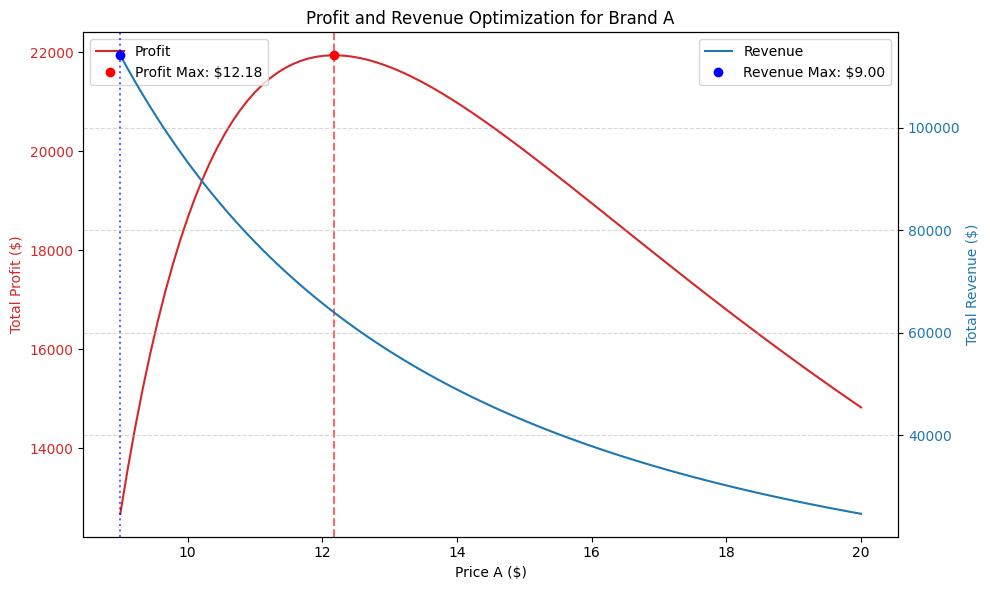


Optimal Price (Profit Max): $12.18
Predicted Max Profit: $21935
Revenue Max Price: $9.00


In [11]:
# --- SOLVE FOR OPTIMAL PRICE ---
# Use a reasonable price range for K-cups (e.g., $9 to $20)
price_range = (9.0, 20.0) 

# Run the minimization (maximization of profit)
result = minimize_scalar(
    profit_A, 
    bounds=price_range, 
    method='bounded',
    args=(COST_A, E_A_fit, E_B_fit, E_C_fit, Intercept_fit, COMP_PRICE_B, COMP_PRICE_C)
)

optimal_price_A = result.x
max_profit = -result.fun # Convert minimized negative profit back to max profit

# --- GENERATE DATA FOR PLOTTING ---
prices_to_test = np.linspace(price_range[0], price_range[1], 100)
profits = []
revenues = []

for p in prices_to_test:
    profits.append((p - COST_A) * demand_A(p, E_A_fit, E_B_fit, E_C_fit, Intercept_fit, COMP_PRICE_B, COMP_PRICE_C))
    revenues.append(revenue_A(p, E_A_fit, E_B_fit, E_C_fit, Intercept_fit, COMP_PRICE_B, COMP_PRICE_C))

# Find the price that maximizes revenue for comparison (Unit Elasticity)
rev_max_price_idx = np.argmax(revenues)
rev_max_price = prices_to_test[rev_max_price_idx]
max_revenue = revenues[rev_max_price_idx]

# --- PLOT THE RESULTS ---
fig, ax1 = plt.subplots(figsize=(10, 6))


color = 'tab:red'
ax1.set_xlabel('Price A ($)')
ax1.set_ylabel('Total Profit ($)', color=color)
ax1.plot(prices_to_test, profits, color=color, label='Profit')
ax1.tick_params(axis='y', labelcolor=color)

# Add Profit Maximum Annotation
ax1.axvline(optimal_price_A, color='red', linestyle='--', alpha=0.6)
ax1.plot(optimal_price_A, max_profit, 'ro', label=f'Profit Max: ${optimal_price_A:.2f}')
ax1.legend(loc='upper left')

# Create a second Y-axis for Revenue
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Total Revenue ($)', color=color)  
ax2.plot(prices_to_test, revenues, color=color, linestyle='-', label='Revenue')
ax2.tick_params(axis='y', labelcolor=color)

# Add Revenue Maximum Annotation
ax2.axvline(rev_max_price, color='blue', linestyle=':', alpha=0.6)
ax2.plot(rev_max_price, max_revenue, 'bo', label=f'Revenue Max: ${rev_max_price:.2f}')
ax2.legend(loc='upper right')

plt.title('Profit and Revenue Optimization for Brand A')
fig.tight_layout() 
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- FINAL SOLUTION ---
print("\n" + "=" * 40)
print(f"Optimal Price (Profit Max): ${optimal_price_A:.2f}")
print(f"Predicted Max Profit: ${max_profit:.0f}")
print(f"Revenue Max Price: ${rev_max_price:.2f}")
print("=" * 40)